In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms

# Input: Image (28x28) -> Hidden Layer 1 (256) -> Hidden Layer 2 (128) -> Mean and Variance ->  Reparameterization Trick -> Hidden Layer 2 (128)-> Hidden Layer 1 (256) ->  Output: Image (28x28)
class VaritionalAutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3 ,latent_dim):
        super(VaritionalAutoEncoder, self).__init__()
        # Encoder
        self.img_2hid1 = nn.Linear(input_dim, hidden_dim_1)
        self.hid1_2hid2 = nn.Linear(hidden_dim_1, hidden_dim_2)
        self.hid2_2hid3 = nn.Linear(hidden_dim_2, hidden_dim_3)
        self.hid3_2mu = nn.Linear(hidden_dim_3, latent_dim)
        self.hid3_2sigma = nn.Linear(hidden_dim_3, latent_dim)

        # Decoder
        self.z_2hid3 = nn.Linear(latent_dim, hidden_dim_3)
        self.hid3_2hid2 = nn.Linear(hidden_dim_3, hidden_dim_2)
        self.hid2_2hid1 = nn.Linear(hidden_dim_2, hidden_dim_1)
        self.hid1_2img = nn.Linear(hidden_dim_1, input_dim) # output dim = input dim

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    # Inference model of VAE
    # q(z|x)
    def encoder(self, x):
        hidden1 = self.relu(self.img_2hid1(x))
        hidden2 = self.relu(self.hid1_2hid2(hidden1))
        hidden3 = self.relu(self.hid2_2hid3(hidden2))
        mu,sigma = self.hid3_2mu(hidden3), self.hid3_2sigma(hidden3)
        return mu, sigma
    
    # Generative model of VAE
    # p(x|z)
    def decoder(self, z):    
        hidden3 = self.relu(self.z_2hid3(z))
        hidden2 = self.relu(self.hid3_2hid2(hidden3))
        hidden1 = self.relu(self.hid2_2hid1(hidden2))
        return torch.sigmoid(self.hid1_2img(hidden1))

    # VAE
    def forward(self, x):
        mu, sigma = self.encoder(x)
        epsilon = torch.randn_like(sigma)
        z = mu + sigma * epsilon
        x_reconstructed = self.decoder(z)
        return x_reconstructed, mu, sigma

938it [00:18, 50.38it/s]
938it [00:21, 44.19it/s]
938it [00:13, 69.00it/s]
938it [00:12, 77.34it/s]
938it [00:12, 77.77it/s]
938it [00:12, 73.71it/s]
938it [00:12, 74.52it/s]
938it [00:11, 78.22it/s]
938it [00:16, 56.60it/s]
938it [00:15, 61.28it/s]
938it [00:11, 79.13it/s] 
938it [00:09, 101.80it/s]
938it [00:08, 106.40it/s]
938it [00:08, 104.72it/s]
938it [00:09, 102.73it/s]
938it [00:08, 106.30it/s]
938it [00:08, 106.08it/s]
938it [00:09, 100.59it/s]
938it [00:08, 105.05it/s]
938it [00:09, 103.56it/s]
938it [00:08, 106.68it/s]
938it [00:09, 103.10it/s]
938it [00:08, 105.70it/s]
938it [00:08, 106.92it/s]
938it [00:09, 103.67it/s]
938it [00:09, 103.81it/s]
938it [00:08, 106.33it/s]
938it [00:08, 105.72it/s]
938it [00:08, 106.81it/s]
938it [00:08, 106.47it/s]


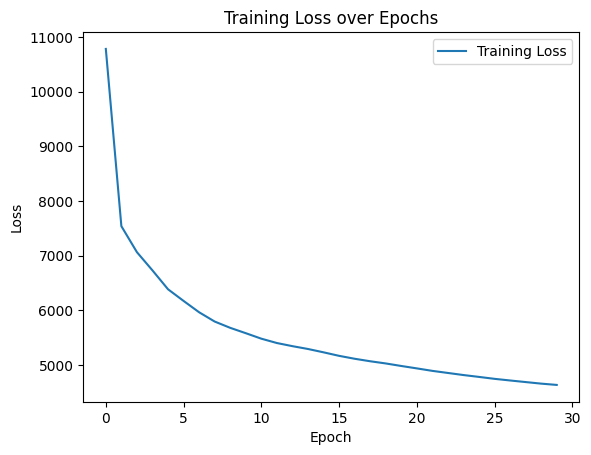

In [2]:

import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from tqdm import tqdm
import numpy as np

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Congfiguration 
input_dim = 784
hidden_dim_1 = 256
hidden_dim_2 = 128
hidden_dim_3 = 64
latent_dim = 20
nb_epochs = 30
bach_size = 64
lr_rate =  0.001

# Dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
val_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=bach_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=bach_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=bach_size, shuffle=False)

# Model
model = VaritionalAutoEncoder(input_dim=input_dim, hidden_dim_1=hidden_dim_1, hidden_dim_2=hidden_dim_2, hidden_dim_3=hidden_dim_3 ,latent_dim=latent_dim).to(device)
model.train()
optimizer = optim.Adam(model.parameters(), lr=lr_rate)

# Training loss 
train_losses = []

# Training loop 
for epoch in range(nb_epochs):
    total_loss = 0
    loop = tqdm(enumerate(train_loader))
    
    for i, (x, _) in loop:
        # Forward pass
        x = x.to(device).view(x.size(0), input_dim)
        x_reconstructed, mu, sigma = model(x)

        # Compute loss
        res_loss = F.binary_cross_entropy(x_reconstructed, x, reduction='sum')
        kl_div = -0.5 * torch.sum(1 + sigma - mu.pow(2) - sigma.exp())
        loss = res_loss + kl_div
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    # Tính loss trung bình cho epoch
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Cập nhật tiến trình
    loop.set_description(f"Epoch [{epoch+1}/{nb_epochs}]")
    loop.set_postfix(loss=avg_loss)

# Plot loss
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

# Convert model to CPU
model = model.to('cpu')

In [11]:
print(model)

VaritionalAutoEncoder(
  (img_2hid1): Linear(in_features=784, out_features=256, bias=True)
  (hid1_2hid2): Linear(in_features=256, out_features=128, bias=True)
  (hid2_2hid3): Linear(in_features=128, out_features=64, bias=True)
  (hid3_2mu): Linear(in_features=64, out_features=20, bias=True)
  (hid3_2sigma): Linear(in_features=64, out_features=20, bias=True)
  (z_2hid3): Linear(in_features=20, out_features=64, bias=True)
  (hid3_2hid2): Linear(in_features=64, out_features=128, bias=True)
  (hid2_2hid1): Linear(in_features=128, out_features=256, bias=True)
  (hid1_2img): Linear(in_features=256, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


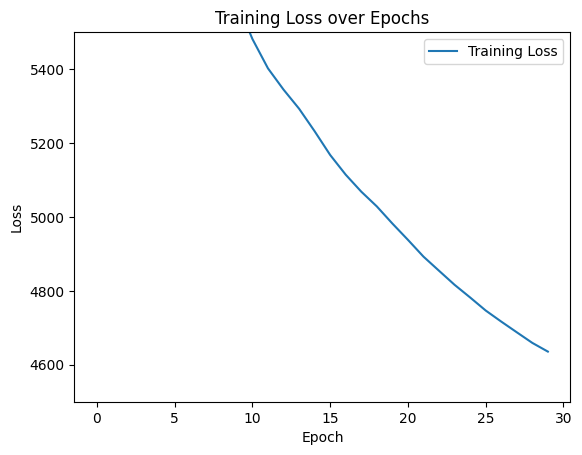

In [10]:
# Plot loss
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylim(4500,5500)
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

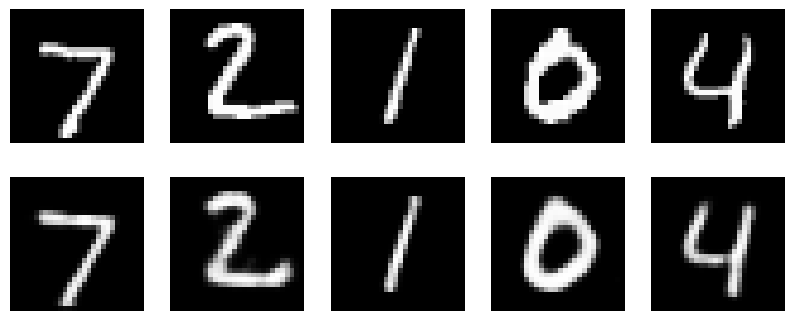

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [4]:
with torch.no_grad(): 
    for i, (x, _) in enumerate(test_loader):
        x = x.to(device).view(x.shape[0], input_dim)
        x_reconstructed, mu, sigma = model(x)
        
        # Display first 5 original and 5 reconstructed images
        if i == 0:
            fig, ax = plt.subplots(2, 5, figsize=(10, 4))
            for j in range(5):
                ax[0, j].imshow(x[j].cpu().numpy().reshape(28, 28), cmap='gray')
                ax[0, j].axis('off')
                ax[1, j].imshow(x_reconstructed[j].cpu().numpy().reshape(28, 28), cmap='gray')
                ax[1, j].axis('off')
            plt.show()
            break

# Check probability distribution of mu and sigma
mu_list = []
sigma_list = []

with torch.no_grad():
    for i, (x, _) in enumerate(test_loader):
        x = x.to(device).view(x.shape[0], input_dim)
        _, mu, sigma = model(x)
        
        mu_list.append(mu.cpu().numpy())
        sigma_list.append(sigma.cpu().numpy())

        if i > 10:  # Get data from first 10 batches
            break   # Stop after getting data from first 10 batches

# Convert to numpy arrays
mu_list = np.concatenate(mu_list, axis=0)
sigma_list = np.concatenate(sigma_list, axis=0)

# Display histograms of mu and sigma
plt.figure(figsize=(12, 6))


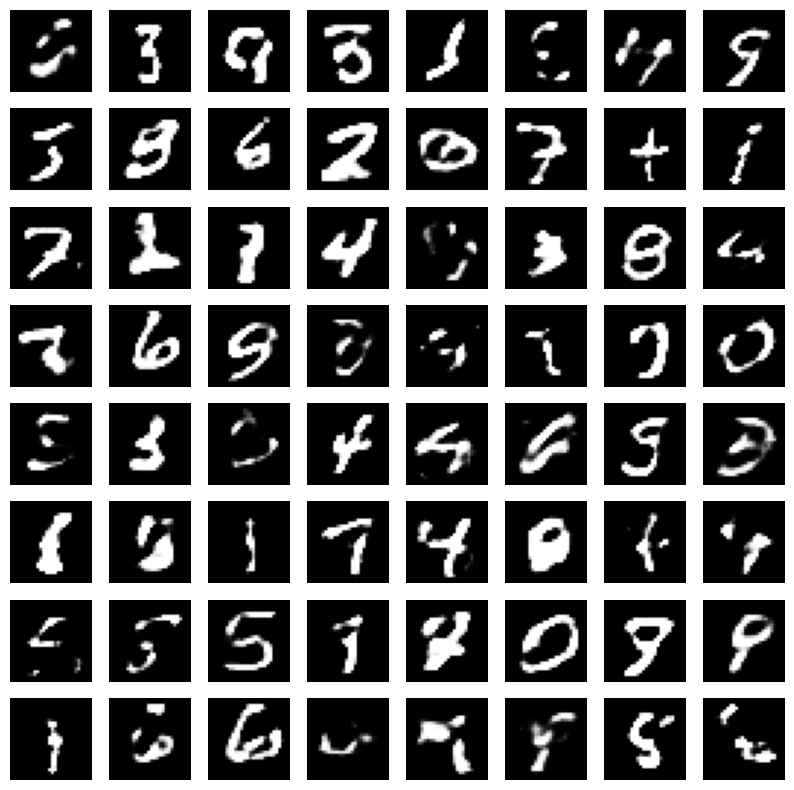

In [5]:
# Generate new images from latent space
with torch.no_grad():
    # Make random vector form distribution normal
    random_z = torch.randn(64, latent_dim).to(device)
    
    # Generate new images
    x_generated = model.decoder(random_z)
    
    # Display generated images
    fig, ax = plt.subplots(8, 8, figsize=(10, 10))
    for i in range(64):
        ax[i // 8, i % 8].imshow(x_generated[i].cpu().numpy().reshape(28, 28), cmap='gray')
        ax[i // 8, i % 8].axis('off')
    plt.show()

In [6]:
def evaluate_model(model, dataloader, input_dim, device):
    """
    Evaluate a Variational Autoencoder model on a given dataset.

    Args:
        model: A Variational Autoencoder model.
        dataloader: A DataLoader object containing the dataset to evaluate on.
        input_dim: The dimensionality of the input data.
        device: The device to run the evaluation on.

    Returns:
        The average reconstruction loss (MSE) on the given dataset.
    """

    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device).view(x.size(0), input_dim) 
            x_reconstructed, _, _ = model(x)
            
            loss = F.mse_loss(x_reconstructed, x, reduction='sum')
            total_loss += loss.item()
    
    # Tính toán lỗi tái tạo trung bình trên tất cả các batch
    avg_loss = total_loss / len(dataloader.dataset)
    print(f"Reconstruction Loss (MSE) on Test Set: {avg_loss:.4f}")
    return avg_loss

# Evaluate model on test set
test_loss = evaluate_model(model, test_loader, input_dim, device)

Reconstruction Loss (MSE) on Test Set: 8.1482
